# 03 · Modelado, selección (validación) y evaluación final (test)

**Protocolo** (`src/models/experiments.py`):
* Validación = temporadas **2021-22 y 2022-23** (760 partidos). Cada temporada se predice con modelos entrenados con
  todas las temporadas anteriores desde 2002-03 (ventana expansiva, reentrenamiento anual). Las features se actualizan
  partido a partido, así que el modelo sigue la temporada aunque sus coeficientes estén fijos.
* Dixon-Coles clásico (sin features) se reajusta cada semana con los partidos anteriores.
* Métrica de selección: **log loss** sobre el resultado 1X2. Secundarias: RPS, Brier, accuracy, ECE y log loss del
  **marcador exacto** (qué probabilidad le dio el modelo al resultado que ocurrió: mide la grilla que muestra la web).
* Todos se comparan con el mercado **en los mismos 760 partidos**. El test (2023-26) **no se tocó**.
* Cada corrida quedó registrada en MLflow (`mlflow.db`, experimento `premier-league-goals`).

In [1]:
import sys
sys.path.insert(0, '..')  # raíz del proyecto, para importar src

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import viz
from src.config import TRAIN_SEASONS, VALIDATION_SEASONS
from src.metrics import OUTCOMES, reliability_table
from src.models.experiments import FEATURE_SETS, PREDICTIONS_DIR, SELECTED_PATH, prepare
from src.models.feature_models import PoissonGLMModel
from src.models.scoreline import outcome_probabilities, score_matrix
from src.features.build import FEATURES_PATH

viz.use_style()
pd.set_option("display.max_columns", 40, "display.width", 180, "display.max_colwidth", 90)
features = prepare(pd.read_parquet(FEATURES_PATH))
results = pd.read_csv(PREDICTIONS_DIR / "validation_results.csv")
vs_market = pd.read_csv(PREDICTIONS_DIR / "validation_vs_market.csv")
selected = json.loads(SELECTED_PATH.read_text(encoding="utf-8"))
print(f"Configuraciones evaluadas en validación: {len(results) - 2} (+ 2 referencias de mercado)")
print(f"Partidos de validación (2021-22 y 2022-23) con cuotas: {int(results.n.iloc[0])}")

2026/09/29 22:29:44 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\lolen\OneDrive\Escritorio\Proy\DS\football-match-predictor\venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


Configuraciones evaluadas en validación: 106 (+ 2 referencias de mercado)
Partidos de validación (2021-22 y 2022-23) con cuotas: 760


## 1 · Mejor configuración de cada familia

In [2]:
cols = ["config", "log_loss", "rps", "brier", "accuracy", "ece", "exact_score_log_loss"]
best = pd.concat([results[results.family == "mercado"], results[results.family != "mercado"].groupby("family").head(1)])
best.sort_values("log_loss")[cols].style.format({c: "{:.4f}" for c in cols[1:]} | {"accuracy": "{:.1%}"}).hide(axis="index")

config,log_loss,rps,brier,accuracy,ece,exact_score_log_loss
mercado_pinnacle_cierre,0.9491,0.1932,0.5626,56.6%,0.0239,nan
mercado_bet365_precierre,0.9511,0.1939,0.5634,57.0%,0.0235,nan
family=poisson_glm|features=elo|alpha=0.0001|halflife_days=None|dixon_coles=False,0.9688,0.1998,0.5755,54.9%,0.0238,2.9729
family=dixon_coles|xi=0.004|l2=1.0,0.9692,0.1997,0.5755,54.5%,0.0221,2.9658
family=xgb_poisson|features=todas|max_depth=2|n_estimators=500|halflife_days=None|dixon_coles=True,0.9693,0.1999,0.5757,54.6%,0.0194,2.9693
family=logit_elo,0.9698,0.1998,0.5759,54.9%,0.0230,nan
family=frecuencias,1.0613,0.2319,0.6413,45.7%,0.0140,nan


**Lectura:**
* **Todos los modelos quedan entre 0,9688 y 0,9698 de log loss**: una diferencia de 0,001 entre el mejor y el peor
  candidato serio. Los intervalos pareados de las diferencias entre familias (celda siguiente) van de ±0,004 a ±0,009
  y todos incluyen el 0: **las familias no se distinguen estadísticamente entre sí**.
* El mejor nominal es también **el más simple**: dos regresiones de Poisson con **solo la diferencia de Elo**. Entre
  modelos que empatan, elegir el más simple es el criterio estándar (navaja de Occam) y además facilita explicarlo.
* **Contra el mercado**: el modelo queda ~0,018 de log loss por detrás de Bet365 pre-cierre y ~0,020 de Pinnacle
  cierre, y esa diferencia **sí es significativa** (tabla de abajo). Es el resultado esperable para un modelo sin
  información de lesiones, alineaciones ni noticias, y se reporta tal cual.
* Todos mejoran ampliamente a la referencia ingenua (frecuencias históricas, 1,061).

In [3]:
from src.models.experiments import paired_bootstrap
preds = {pd.read_parquet(p).config.iloc[0]: pd.read_parquet(p) for p in PREDICTIONS_DIR.glob("validation_*.parquet")}
best_cfg = results[results.family != "mercado"].groupby("family").head(1).set_index("family").config
ref = preds[best_cfg["poisson_glm"]]
rows = [{"familia": fam, **paired_bootstrap(preds[best_cfg[fam]], ref, features)}
        for fam in ("xgb_poisson", "dixon_coles", "logit_elo") if best_cfg[fam] in preds]
pd.DataFrame(rows).style.format({"diff": "{:+.4f}", "ci_low": "{:+.4f}", "ci_high": "{:+.4f}"}).hide(axis="index")

familia,n,diff,ci_low,ci_high
xgb_poisson,760,+0.0005,-0.0052,+0.0061
dixon_coles,760,+0.0003,-0.0085,+0.0090
logit_elo,760,+0.0009,-0.0028,+0.0047


## 2 · ¿Qué aportan las features, la corrección de Dixon-Coles y el decaimiento temporal?

Mejor log loss de la regresión de Poisson según el conjunto de features y la corrección de marcadores bajos:

In [4]:
glm = results[results.family == "poisson_glm"].copy()
glm["halflife_days"] = glm.halflife_days.fillna("sin decaimiento")
pivot = glm.groupby(["features", "dixon_coles"]).log_loss.min().unstack()
pivot.columns = ["Poisson independiente", "con corrección Dixon-Coles"]
pivot.reindex(list(FEATURE_SETS)).style.format("{:.4f}").highlight_min(axis=None, color="#cde2fb")

,Poisson independiente,con corrección Dixon-Coles
features,,
elo,0.9688,0.9692
elo+goles,0.9698,0.9701
elo+goles+sin_publico,0.9699,0.9702
elo+goles+tabla+sin_publico,0.9713,0.9716
todas,0.9718,0.9722


In [5]:
glm.groupby("halflife_days").log_loss.min().to_frame("mejor log loss").style.format("{:.4f}")

,mejor log loss
halflife_days,
730.000000,0.9711
1460.000000,0.9695
sin decaimiento,0.9688


* **Agregar features al Elo no mejora** (empeora levemente al sumar tabla y el resto): el Elo ya resume la fuerza de
  cada equipo y el resto es redundante, como anticipó el notebook 02. Es coherente con Hvattum y Arntzen (2010), donde
  el Elo como única covariable competía con modelos más complejos.
* **La corrección de Dixon-Coles no mejora el 1X2** en validación (diferencias de 0,0004). El EDA ya mostraba
  evidencia mixta en marcadores bajos.
* **El decaimiento temporal tampoco** (tabla de abajo): el Elo ya pondera lo reciente por construcción.

## 3 · Comparación pareada contra el mercado (bootstrap, 5.000 remuestreos)

`diff` = log loss del modelo − log loss del mercado en los mismos partidos (positivo = el mercado es mejor).

In [6]:
vm = vs_market.copy()
vm["significativo"] = np.where(vm.ci_high < 0, "modelo mejor", np.where(vm.ci_low > 0, "mercado mejor", "sin diferencia clara"))
vm[["config", "vs", "n", "diff", "ci_low", "ci_high", "significativo"]].style.format(
    {"diff": "{:+.4f}", "ci_low": "{:+.4f}", "ci_high": "{:+.4f}"}).hide(axis="index")

config,vs,n,diff,ci_low,ci_high,significativo
family=poisson_glm|features=elo|alpha=0.0001|halflife_days=None|dixon_coles=False,mercado_bet365_precierre,760,+0.0177,+0.0061,+0.0292,mercado mejor
family=poisson_glm|features=elo|alpha=0.0001|halflife_days=None|dixon_coles=False,mercado_pinnacle_cierre,760,+0.0197,+0.0078,+0.0318,mercado mejor
family=dixon_coles|xi=0.004|l2=1.0,mercado_bet365_precierre,760,+0.0180,+0.0069,+0.0294,mercado mejor
family=dixon_coles|xi=0.004|l2=1.0,mercado_pinnacle_cierre,760,+0.0201,+0.0083,+0.0320,mercado mejor
family=xgb_poisson|features=todas|max_depth=2|n_estimators=500|halflife_days=None|dixon_coles=True,mercado_bet365_precierre,760,+0.0182,+0.0066,+0.0296,mercado mejor
family=xgb_poisson|features=todas|max_depth=2|n_estimators=500|halflife_days=None|dixon_coles=True,mercado_pinnacle_cierre,760,+0.0202,+0.0082,+0.0321,mercado mejor
family=logit_elo,mercado_bet365_precierre,760,+0.0186,+0.0067,+0.0309,mercado mejor
family=logit_elo,mercado_pinnacle_cierre,760,+0.0206,+0.0082,+0.0336,mercado mejor
family=frecuencias,mercado_bet365_precierre,760,+0.1101,+0.0779,+0.1423,mercado mejor
family=frecuencias,mercado_pinnacle_cierre,760,+0.1121,+0.0805,+0.1436,mercado mejor


## 4 · El modelo elegido

Coeficientes sobre la feature estandarizada (reentrenado con entrenamiento + validación, como se usará en test):

In [7]:
cfg = selected["poisson_glm"]
train = features[features.season_start.isin(range(min(TRAIN_SEASONS), max(VALIDATION_SEASONS) + 1)) & features.played]
model = PoissonGLMModel(FEATURE_SETS[cfg["features"]], alpha=cfg["alpha"], dixon_coles=cfg["dixon_coles"],
                        halflife_days=cfg["halflife_days"]).fit(train)
print(f"Modelo elegido: {cfg}\nrho de Dixon-Coles estimado: {model.rho_:+.4f}")
coefs = model.coefficients()
coefs["efecto en goles del local (x por +1 desvío)"] = np.exp(coefs.goles_local)
coefs["efecto en goles del visitante"] = np.exp(coefs.goles_visitante)
coefs.style.format("{:+.3f}", subset=["goles_local", "goles_visitante"]).format("{:.3f}", subset=coefs.columns[2:])

Modelo elegido: {'family': 'poisson_glm', 'features': 'elo', 'alpha': 0.0001, 'dixon_coles': False, 'halflife_days': None}
rho de Dixon-Coles estimado: +0.0000


,goles_local,goles_visitante,efecto en goles del local (x por +1 desvío),efecto en goles del visitante
elo_diff,+0.300,-0.312,1.350,0.732


Un desvío estándar más de diferencia de Elo a favor del local (~180 puntos) multiplica sus goles esperados por ~1,35 y
los del visitante por ~0,73 (columnas exponenciadas). La corrección de Dixon-Coles no forma parte del modelo elegido
(rho = 0).

## 5 · Calibración en validación

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


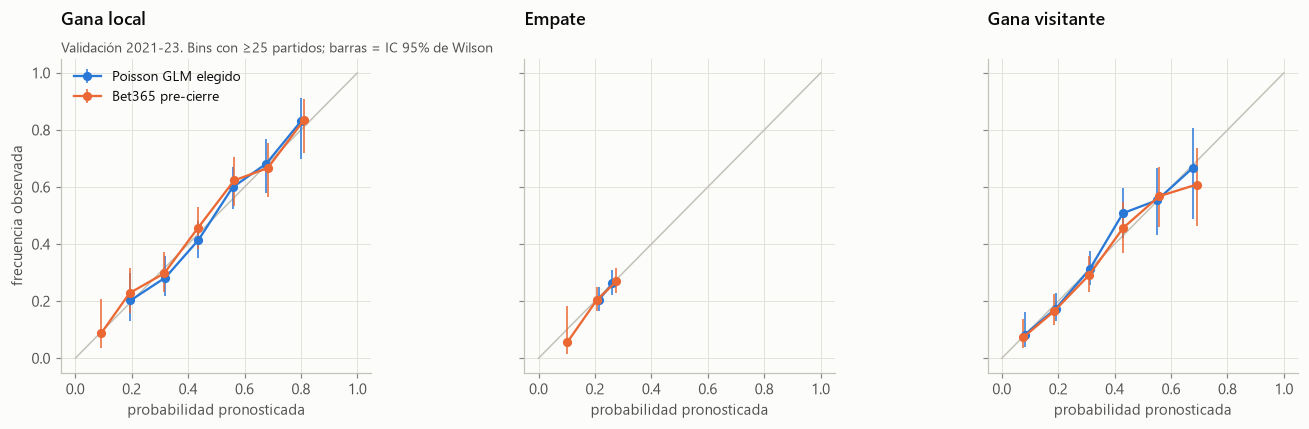

In [8]:
glm_pred = pd.read_parquet(next(p for p in PREDICTIONS_DIR.glob("validation_*.parquet")
                                if pd.read_parquet(p).config.iloc[0] == results[results.family == "poisson_glm"].config.iloc[0]))
b365_pred = pd.read_parquet(next(p for p in PREDICTIONS_DIR.glob("validation_*.parquet")
                                 if pd.read_parquet(p).config.iloc[0] == "mercado_bet365_precierre"))
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
labels = {"H": "Gana local", "D": "Empate", "A": "Gana visitante"}
for ax, outcome in zip(axes, OUTCOMES):
    ax.plot([0, 1], [0, 1], color=viz.AXIS, linewidth=1)
    for pred, name, color in [(glm_pred, "Poisson GLM elegido", viz.BLUE), (b365_pred, "Bet365 pre-cierre", viz.ORANGE)]:
        d = pred.merge(features[["match_id", "result"]], on="match_id")
        t = reliability_table(d[["p_home", "p_draw", "p_away"]].to_numpy(), d.result.to_numpy(), n_bins=8)
        t = t[(t.outcome == outcome) & (t.n >= 25)]
        ax.errorbar(t.mean_predicted, t.observed, yerr=[t.observed - t.ci_low, t.ci_high - t.observed],
                    fmt="o-", color=color, markersize=5, linewidth=1.5, elinewidth=1, label=name)
    ax.set_title(labels[outcome]); ax.set_xlabel("probabilidad pronosticada"); ax.grid(True, axis="both")
axes[0].set_ylabel("frecuencia observada"); axes[0].legend(loc="upper left")
viz.subtitle(axes[0], "Validación 2021-23. Bins con ≥25 partidos; barras = IC 95% de Wilson")
fig.tight_layout(); fig.savefig("../reports/figures/model_calibration_validation.png"); plt.show()

El modelo está razonablemente calibrado en los tres resultados, con intervalos que se superponen a los del mercado.
Ni el modelo ni el mercado asignan probabilidades de empate por encima de ~30%: el empate es el resultado más difícil
de anticipar.

## 6 · La salida del producto: grilla de marcadores exactos

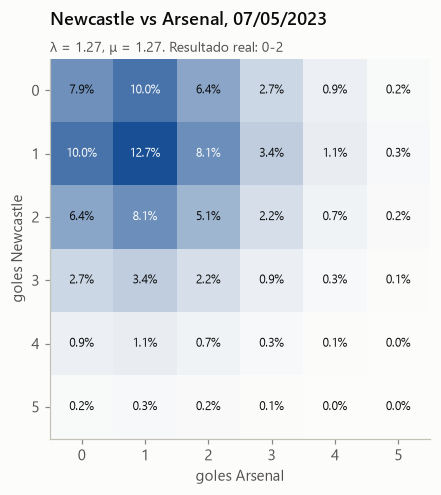

In [9]:
# Ejemplo de la salida principal del producto: la grilla de marcadores exactos de un partido de validación.
ex = glm_pred.merge(features[["match_id", "date", "home_team", "away_team", "home_goals", "away_goals"]], on="match_id")
row = ex.iloc[(ex.lam - ex.mu).abs().argsort().iloc[0]]  # un partido parejo
m = score_matrix([row.lam], [row.mu], row.rho)[0][:6, :6]
fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(m, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("s", ["#fcfcfb", viz.SEQUENTIAL_BLUE[-2]]))
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{m[i, j]:.1%}", ha="center", va="center", fontsize=8, color="white" if m[i, j] > 0.08 else viz.INK)
ax.set_xticks(range(6)); ax.set_yticks(range(6)); ax.grid(False)
ax.set_xlabel(f"goles {row.away_team}"); ax.set_ylabel(f"goles {row.home_team}")
ax.set_title(f"{row.home_team} vs {row.away_team}, {row.date:%d/%m/%Y}")
viz.subtitle(ax, f"λ = {row.lam:.2f}, μ = {row.mu:.2f}. Resultado real: {int(row.home_goals)}-{int(row.away_goals)}")
fig.tight_layout(); plt.show()

## 7 · Decisión

**Modelo principal: Poisson con diferencia de Elo** (el más simple y el mejor nominal en validación). Para el test se
evalúa además la mejor configuración de cada familia, **elegida acá**, para reportar la comparación completa.
El test se corre una sola vez (sección 8).

## 8 · Evaluación final en test (2023-24 a 2025-26) — corrida una sola vez

Se evalúan las configuraciones elegidas en validación (una por familia), reentrenadas al inicio de cada temporada con
todo lo anterior, incluida validación. **Nota sobre las muestras:** todos los modelos y Bet365 se evalúan en los 1.140
partidos; Pinnacle cierre solo existe en 970 (cubre el 55% de 2025-26), así que su fila de la tabla usa esa muestra
menor. Las comparaciones pareadas de más abajo usan siempre los partidos comunes.

In [10]:
from src.metrics import summarize
test_results = pd.read_csv(PREDICTIONS_DIR / "test_results.csv")
test_vs_market = pd.read_csv(PREDICTIONS_DIR / "test_vs_market.csv")
test_preds = {pd.read_parquet(p).config.iloc[0]: pd.read_parquet(p) for p in PREDICTIONS_DIR.glob("test_*.parquet")}
cols = ["config", "n", "log_loss", "rps", "brier", "accuracy", "ece", "exact_score_log_loss"]
test_results[cols].style.format({c: "{:.4f}" for c in cols[2:]} | {"accuracy": "{:.1%}", "n": "{:,.0f}"}).hide(axis="index")

config,n,log_loss,rps,brier,accuracy,ece,exact_score_log_loss
mercado_pinnacle_cierre,970,0.9443,0.1906,0.5591,56.2%,0.0187,nan
mercado_bet365_precierre,"1,140",0.9657,0.1956,0.5744,54.2%,0.0227,nan
family=dixon_coles|xi=0.004|l2=1.0,"1,140",0.9877,0.2027,0.5891,52.3%,0.0233,2.9980
family=poisson_glm|features=elo|alpha=0.0001|dixon_coles=False|halflife_days=None,"1,140",0.9879,0.2030,0.5896,51.6%,0.0215,3.0018
family=xgb_poisson|features=todas|dixon_coles=True|max_depth=2|n_estimators=500|halflife_days=None,"1,140",0.9895,0.2035,0.5905,51.7%,0.0277,2.9934
family=logit_elo,"1,140",0.9901,0.2036,0.5907,51.6%,0.0241,nan
family=frecuencias,"1,140",1.0746,0.2329,0.6507,43.2%,0.0193,nan


Desglose por temporada (para Pinnacle, 2025-26 es solo el subconjunto con cuotas):

In [11]:
pinnacle_ids = set(test_preds["mercado_pinnacle_cierre"].match_id)
rows = []
for name, pred in test_preds.items():
    d = pred.merge(features[["match_id", "season", "result"]], on="match_id")
    for season, g in d.groupby("season"):
        rows.append({"modelo": name.split("|")[0], "temporada": season, "log_loss": summarize(g[["p_home", "p_draw", "p_away"]].to_numpy(), g.result.to_numpy())["log_loss"]})
    g = d[d.match_id.isin(pinnacle_ids)]
    rows.append({"modelo": name.split("|")[0], "temporada": "muestra común con Pinnacle", "log_loss": summarize(g[["p_home", "p_draw", "p_away"]].to_numpy(), g.result.to_numpy())["log_loss"]})
by_season = pd.DataFrame(rows).pivot(index="modelo", columns="temporada", values="log_loss")
by_season.sort_values("muestra común con Pinnacle").style.format("{:.4f}")

temporada,2023-24,2024-25,2025-26,muestra común con Pinnacle
modelo,,,,
mercado_pinnacle_cierre,0.8984,0.9666,0.9869,0.9443
mercado_bet365_precierre,0.9070,0.9708,1.0194,0.9501
family=poisson_glm,0.9292,0.9944,1.0402,0.9722
family=logit_elo,0.9309,0.9976,1.0417,0.9736
family=dixon_coles,0.9407,0.9852,1.0370,0.9737
family=xgb_poisson,0.9361,0.9937,1.0387,0.9743
family=frecuencias,1.0567,1.0851,1.0820,1.0704


* **El resultado de validación se confirma:** las familias vuelven a empatar (Dixon-Coles 0,9877, Poisson + Elo 0,9879,
  XGBoost 0,9895). Nada complejo le gana al modelo simple.
* **2025-26 fue una temporada difícil de predecir para todos**: incluso Bet365 supera 1,0 de log loss. La distancia
  al mercado se mantiene estable temporada a temporada (≈0,02-0,03), lo que indica que el modelo no se degrada con el tiempo.

Diferencia pareada contra el mercado (`diff` = modelo − mercado; positivo = el mercado es mejor):

In [12]:
vm = test_vs_market.copy()
vm["config"] = vm.config.str.split("|").str[0]
vm["significativo"] = np.where(vm.ci_high < 0, "modelo mejor", np.where(vm.ci_low > 0, "mercado mejor", "sin diferencia clara"))
vm.style.format({"diff": "{:+.4f}", "ci_low": "{:+.4f}", "ci_high": "{:+.4f}"}).hide(axis="index")

config,vs,n,diff,ci_low,ci_high,significativo
family=dixon_coles,mercado_bet365_precierre,1140,+0.0219,+0.0125,+0.0315,mercado mejor
family=dixon_coles,mercado_pinnacle_cierre,970,+0.0294,+0.0185,+0.0403,mercado mejor
family=poisson_glm,mercado_bet365_precierre,1140,+0.0222,+0.0132,+0.0312,mercado mejor
family=poisson_glm,mercado_pinnacle_cierre,970,+0.0279,+0.0169,+0.0382,mercado mejor
family=xgb_poisson,mercado_bet365_precierre,1140,+0.0238,+0.0144,+0.0330,mercado mejor
family=xgb_poisson,mercado_pinnacle_cierre,970,+0.0300,+0.0191,+0.0407,mercado mejor
family=logit_elo,mercado_bet365_precierre,1140,+0.0243,+0.0142,+0.0345,mercado mejor
family=logit_elo,mercado_pinnacle_cierre,970,+0.0293,+0.0178,+0.0407,mercado mejor
family=frecuencias,mercado_bet365_precierre,1140,+0.1089,+0.0839,+0.1323,mercado mejor
family=frecuencias,mercado_pinnacle_cierre,970,+0.1261,+0.0989,+0.1526,mercado mejor


**Conclusión honesta:** el modelo principal queda **≈0,022 de log loss por detrás de Bet365 pre-cierre** y **≈0,028 de
Pinnacle cierre**, con intervalos que excluyen el 0. **No supera al mercado.** Sí supera por amplio margen a la
referencia ingenua y está bien calibrado (abajo), así que sus probabilidades son confiables como probabilidades, que
es lo que la web necesita mostrar. La brecha es consistente con lo que el modelo no ve: lesiones, alineaciones,
rotaciones por copas y noticias de la semana.

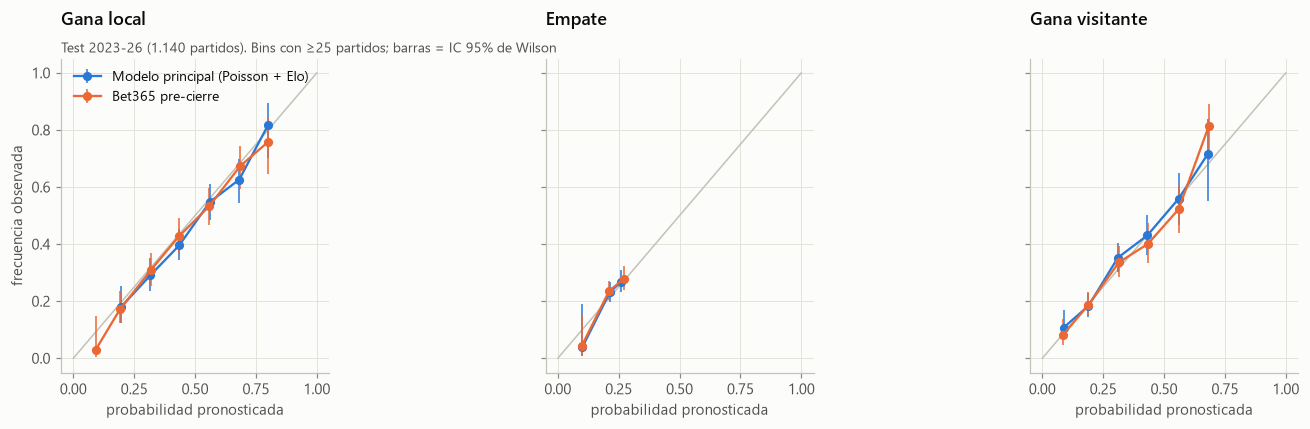

In [13]:
main_name = next(k for k in test_preds if k.startswith("family=poisson_glm"))
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
for ax, outcome in zip(axes, OUTCOMES):
    ax.plot([0, 1], [0, 1], color=viz.AXIS, linewidth=1)
    for name, label, color in [(main_name, "Modelo principal (Poisson + Elo)", viz.BLUE), ("mercado_bet365_precierre", "Bet365 pre-cierre", viz.ORANGE)]:
        d = test_preds[name].merge(features[["match_id", "result"]], on="match_id")
        t = reliability_table(d[["p_home", "p_draw", "p_away"]].to_numpy(), d.result.to_numpy(), n_bins=8)
        t = t[(t.outcome == outcome) & (t.n >= 25)]
        ax.errorbar(t.mean_predicted, t.observed, yerr=[t.observed - t.ci_low, t.ci_high - t.observed],
                    fmt="o-", color=color, markersize=5, linewidth=1.5, elinewidth=1, label=label)
    ax.set_title(labels[outcome]); ax.set_xlabel("probabilidad pronosticada"); ax.grid(True, axis="both")
axes[0].set_ylabel("frecuencia observada"); axes[0].legend(loc="upper left")
viz.subtitle(axes[0], "Test 2023-26 (1.140 partidos). Bins con ≥25 partidos; barras = IC 95% de Wilson")
fig.tight_layout(); fig.savefig("../reports/figures/model_calibration_test.png"); plt.show()

## 9 · Modelo que va a producción

**Poisson + diferencia de Elo** (dos regresiones de Poisson; sin corrección de Dixon-Coles porque no mejoró en validación).
Es el más simple, empata con los más complejos y da directamente la grilla de marcadores exactos que muestra la web.